# Scenario Tree Fan Visualization

Visualizes the two-stage scenario tree from `data/scenarios/copula_tree.csv`.

| Stage | Label | Count |
|-------|-------|-------|
| t=0 | Root (last close) | 1 |
| t=1 | Recourse (copula-sampled) | 400 |
| t=2 | Evaluate (U(0.9,1.1) noise) | 16,000 |

Two fan styles are shown:
- **Spaghetti fan** — sampled individual paths, coloured by t=1 return (red = down, green = up)
- **Percentile fan** — shaded bands for the 5/25/75/95th percentile spread

In [2]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.patches import Patch
from pathlib import Path

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 9,
})

In [3]:
# ── constants ────────────────────────────────────────────────────────────────
TICKERS = sorted([
    'MMM', 'AMZN', 'AXP', 'AMGN', 'AAPL',
    'BA',  'CAT',  'CVX', 'CSCO', 'KO',
    'DIS', 'GS',   'HD',  'HON',  'IBM',
    'JNJ', 'JPM',  'MCD', 'MRK',  'MSFT',
    'NKE', 'NVDA', 'PG',  'CRM',  'SHW',
    'TRV', 'UNH',  'VZ',  'V',    'WMT',
])

RAW_DIR   = Path('../data/raw')
CSV_PATH  = Path('../data/scenarios/tcvae_vine_tree0.csv')
N_ASSETS  = len(TICKERS)   # 30
N_RECOURSE = 150 # 400
N_EVALUATE = 20 # 40

# ── root prices (last close) ─────────────────────────────────────────────────
prices_df     = pd.DataFrame({t: np.load(RAW_DIR / f'{t}.npy') for t in TICKERS})
returns_df    = (prices_df / prices_df.shift(1) - 1.0).dropna()
initial_prices = prices_df.iloc[-1].to_numpy()   # shape (30,)

# ── scenario tree CSV ────────────────────────────────────────────────────────
# columns: [j | p_j | p_je | 30 recourse prices | 30 evaluate prices]
raw_df = pd.read_csv(CSV_PATH, header=None, dtype=np.float64)

# Recourse prices are repeated N_EVALUATE times per recourse node; take unique rows.
recourse_prices = raw_df.iloc[::N_EVALUATE, 3:3+N_ASSETS].to_numpy()          # (400, 30)
evaluate_prices = raw_df.iloc[:, 3+N_ASSETS:3+2*N_ASSETS].to_numpy()          # (16000, 30)
evaluate_3d     = evaluate_prices.reshape(N_RECOURSE, N_EVALUATE, N_ASSETS)    # (400, 40, 30)

# Recourse prices repeated for each evaluate row (needed for conditional returns)
recourse_rep    = raw_df.iloc[:, 3:3+N_ASSETS].to_numpy()                      # (16000, 30)

print(f'Root prices shape : {initial_prices.shape}')
print(f'Recourse prices   : {recourse_prices.shape}')
print(f'Evaluate prices   : {evaluate_3d.shape}')
print(f'\nTickers ({N_ASSETS}): {TICKERS}')

Root prices shape : (30,)
Recourse prices   : (150, 30)
Evaluate prices   : (150, 20, 30)

Tickers (30): ['AAPL', 'AMGN', 'AMZN', 'AXP', 'BA', 'CAT', 'CRM', 'CSCO', 'CVX', 'DIS', 'GS', 'HD', 'HON', 'IBM', 'JNJ', 'JPM', 'KO', 'MCD', 'MMM', 'MRK', 'MSFT', 'NKE', 'NVDA', 'PG', 'SHW', 'TRV', 'UNH', 'V', 'VZ', 'WMT']


## Spaghetti Fan

Each line is one sampled scenario path: **root → recourse node → each of its 40 evaluate children**.
Lines are coloured by the t=1 return: <span style='color:green'>green = up</span>, <span style='color:red'>red = down</span>.

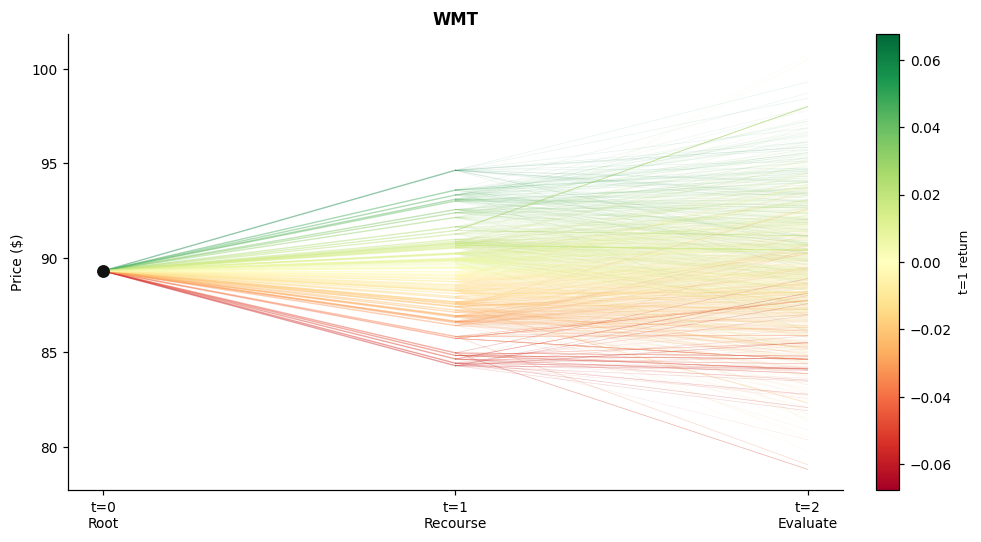

In [4]:
def plot_spaghetti_fan(
    ticker_or_idx,
    n_sample: int = 60,
    seed: int = 42,
    ax=None,
    show_colorbar: bool = True,
):
    """Spaghetti fan for one asset."""
    idx    = TICKERS.index(ticker_or_idx) if isinstance(ticker_or_idx, str) else ticker_or_idx
    ticker = TICKERS[idx]
    p0     = initial_prices[idx]
    rp     = recourse_prices[:, idx]          # (400,)
    ep     = evaluate_3d[:, :, idx]           # (400, 40)

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(9, 5))

    rng     = np.random.default_rng(seed)
    sampled = rng.choice(N_RECOURSE, size=min(n_sample, N_RECOURSE), replace=False)

    ret1  = rp / p0 - 1.0
    vmax  = max(abs(ret1.min()), abs(ret1.max()))
    norm  = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    cmap  = cm.RdYlGn

    for j in sampled:
        colour = cmap(norm(ret1[j]))
        ax.plot([0, 1], [p0, rp[j]], color=colour, alpha=0.45, lw=0.9)
        for e in range(N_EVALUATE):
            ax.plot([1, 2], [rp[j], ep[j, e]], color=colour, alpha=0.10, lw=0.4)

    ax.scatter([0], [p0], color='#111', s=55, zorder=6)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['t=0\nRoot', 't=1\nRecourse', 't=2\nEvaluate'])
    ax.set_ylabel('Price ($)')
    ax.set_title(ticker, fontweight='bold')

    if standalone and show_colorbar:
        sm = cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=-vmax, vmax=vmax))
        sm.set_array([])
        cb = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.04)
        cb.set_label('t=1 return', fontsize=8)
        plt.tight_layout()
        plt.show()


# ── single-asset demo ─────────────────────────────────────────────────────────
DEMO_TICKER = 'WMT'   # <── change to any ticker
plot_spaghetti_fan(DEMO_TICKER, n_sample=80)

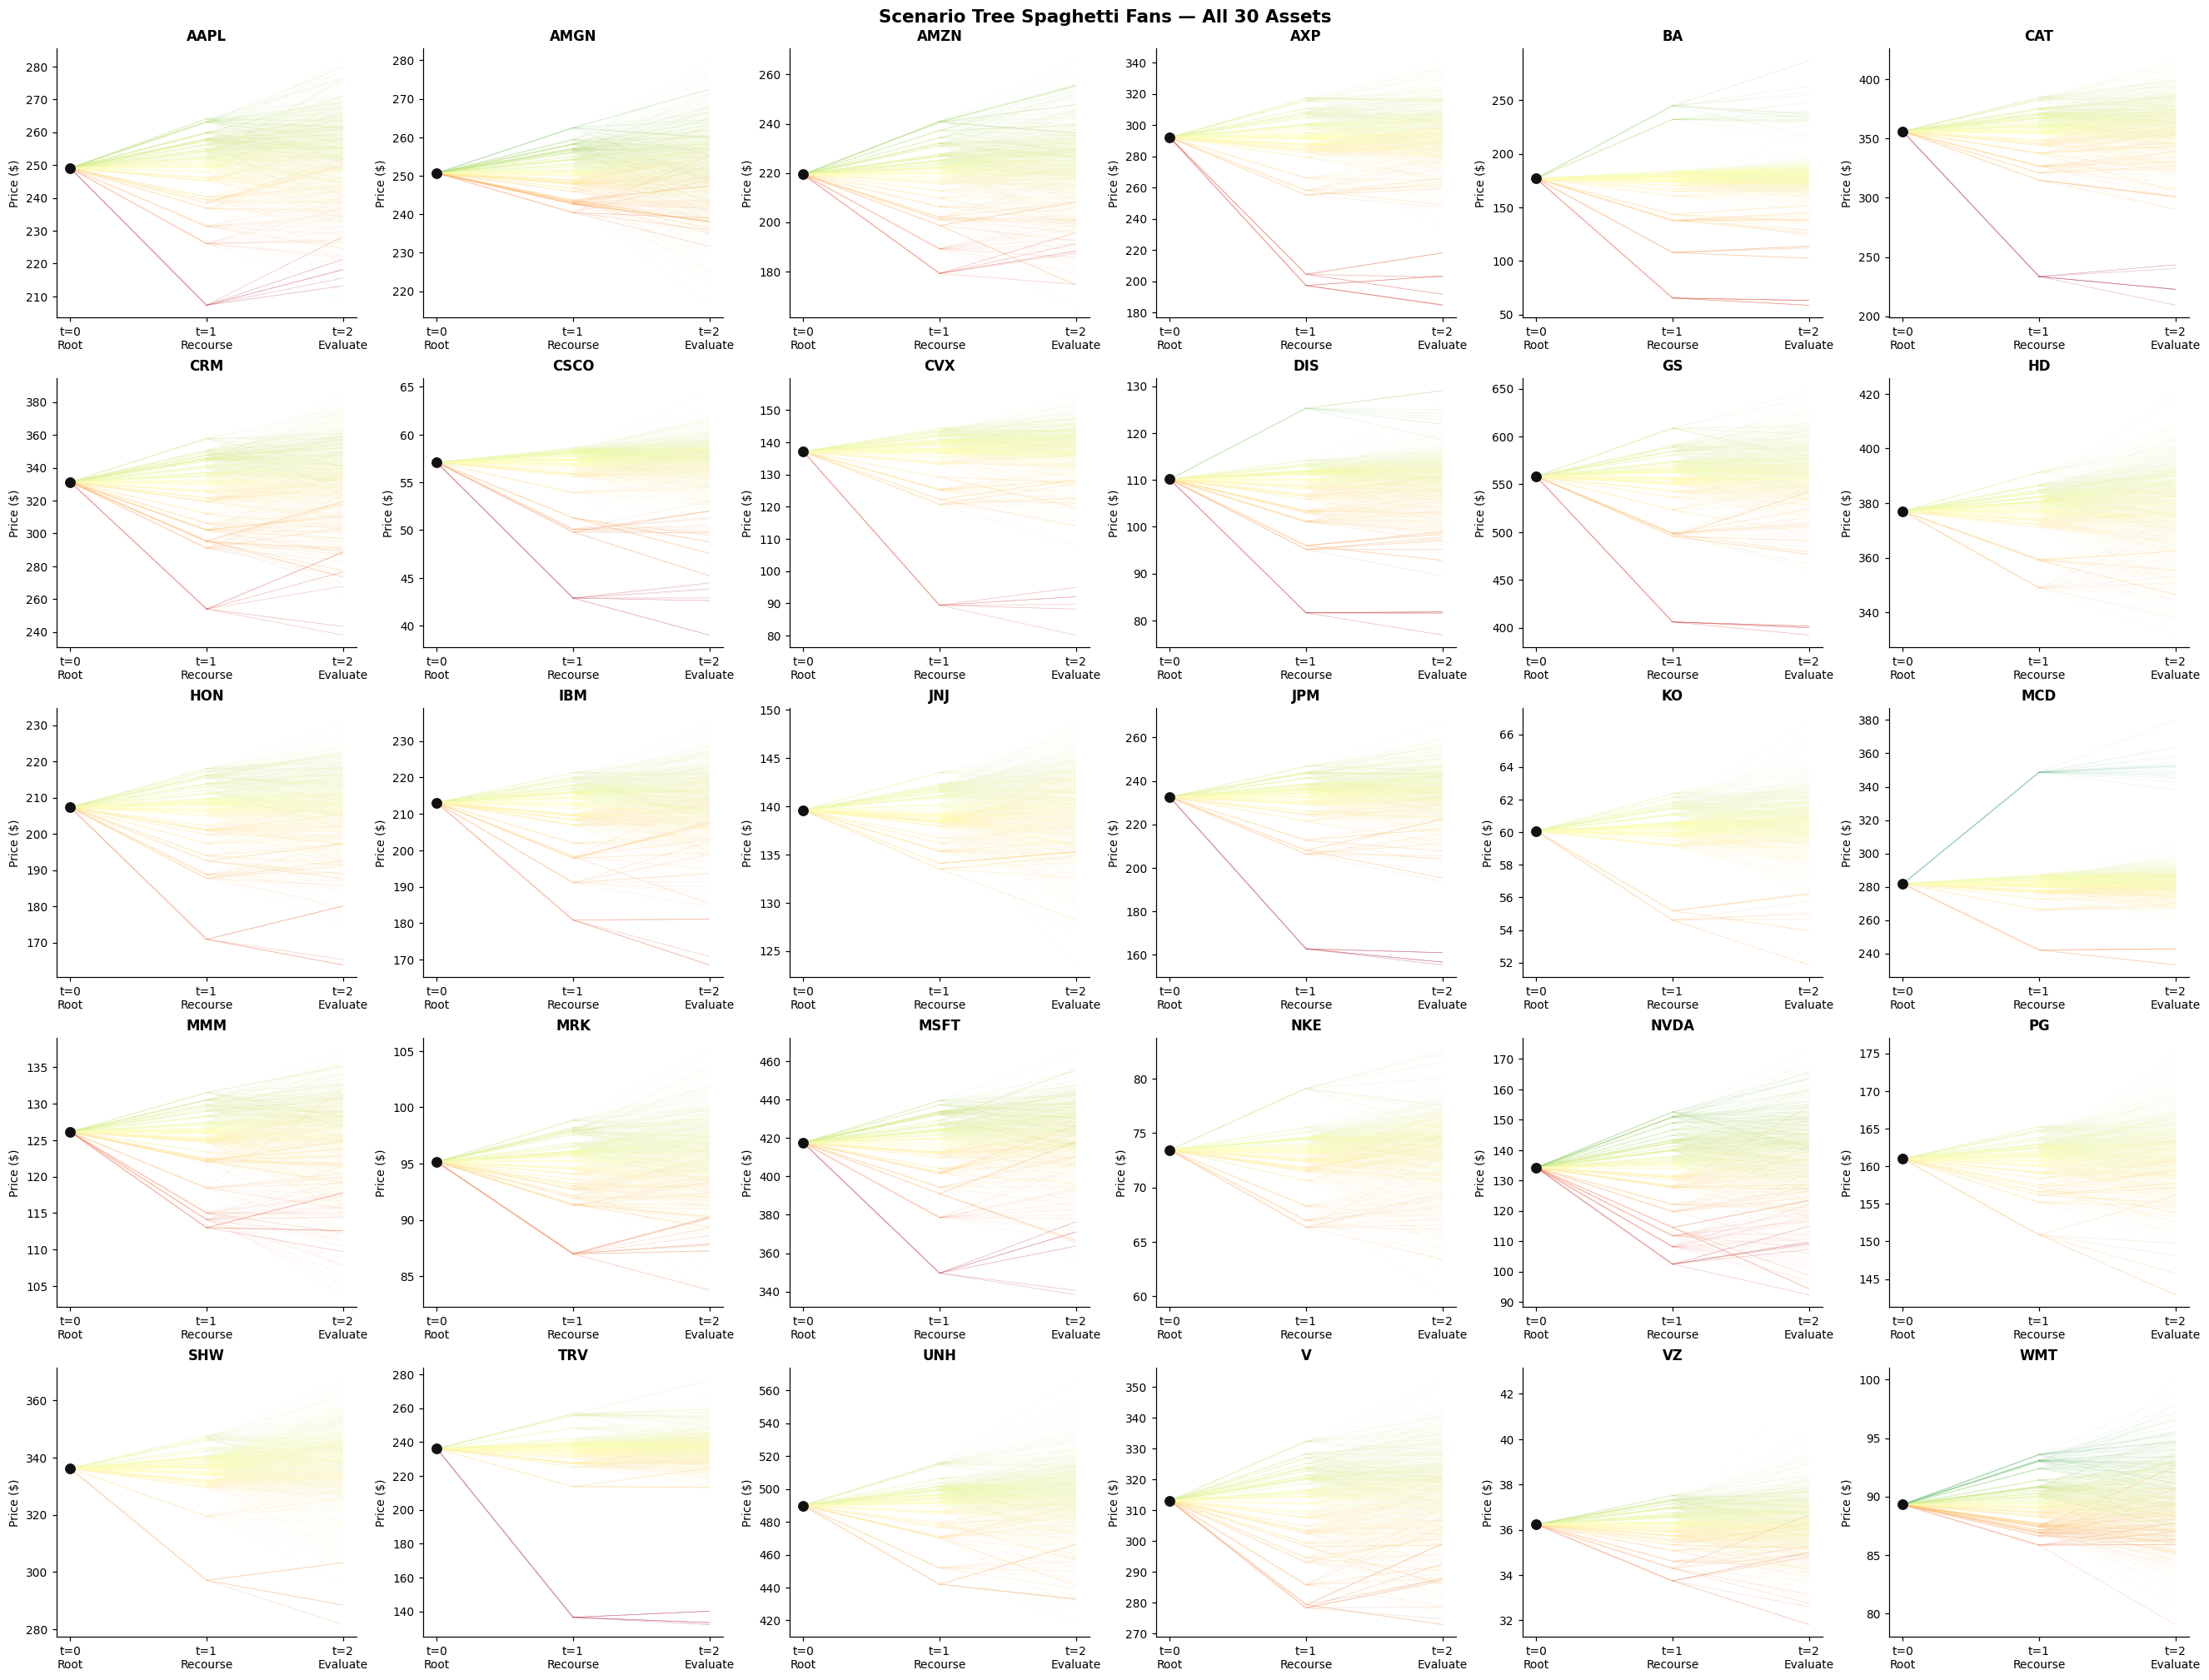

In [5]:
# ── all-assets spaghetti grid ─────────────────────────────────────────────────
NCOLS = 6
NROWS = int(np.ceil(N_ASSETS / NCOLS))   # 5

fig, axes = plt.subplots(NROWS, NCOLS, figsize=(24, NROWS * 3.6), constrained_layout=True)
fig.suptitle('Scenario Tree Spaghetti Fans — All 30 Assets', fontsize=14, fontweight='bold', y=1.01)

for ax, ticker in zip(axes.ravel(), TICKERS):
    plot_spaghetti_fan(ticker, n_sample=40, ax=ax)

for ax in axes.ravel()[N_ASSETS:]:
    ax.set_visible(False)

plt.show()

## Percentile Fan

Shows the **spread** of prices at each stage as shaded bands:

| Band | Shade |
|------|-------|
| 5 – 95 % | lightest |
| 10 – 90 % | medium |
| 25 – 75 % | darkest |

The dashed line is the median path.

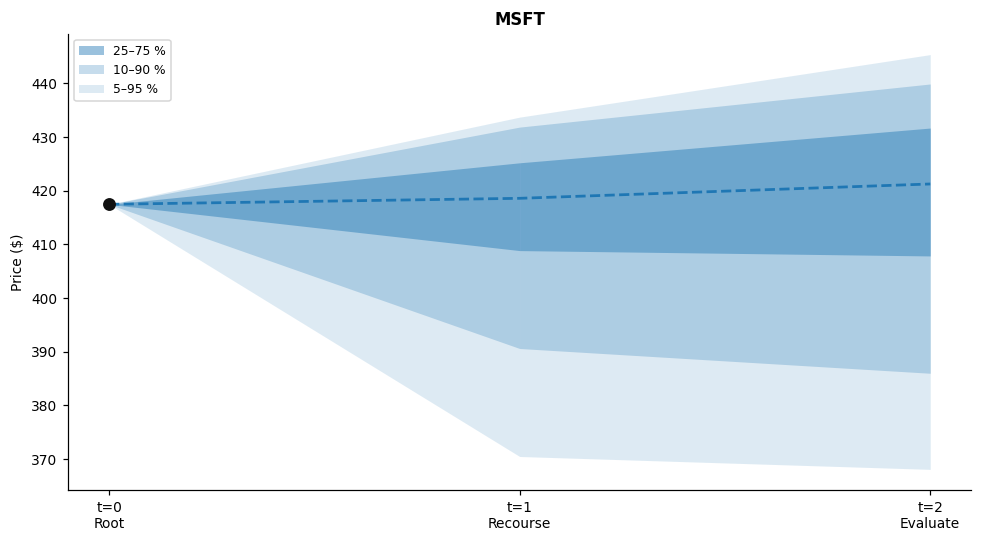

In [6]:
def plot_percentile_fan(ticker_or_idx, colour='#1f77b4', ax=None):
    """BBC-style shaded-band fan chart for one asset."""
    idx    = TICKERS.index(ticker_or_idx) if isinstance(ticker_or_idx, str) else ticker_or_idx
    ticker = TICKERS[idx]
    p0     = initial_prices[idx]
    rp     = recourse_prices[:, idx]               # (400,)
    ep     = evaluate_3d[:, :, idx].ravel()         # (16000,) — all leaves pooled

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(9, 5))

    band_pairs = [(5, 95), (10, 90), (25, 75)]
    alphas     = [0.15,    0.25,     0.45   ]

    for (lo, hi), alpha in zip(band_pairs, alphas):
        lo_r, hi_r = np.percentile(rp, lo), np.percentile(rp, hi)
        lo_e, hi_e = np.percentile(ep, lo), np.percentile(ep, hi)
        # Widening fan from t=0 (single point) → t=1 → t=2
        ax.fill_between([0, 1], [p0, lo_r], [p0, hi_r], color=colour, alpha=alpha, lw=0)
        ax.fill_between([1, 2], [lo_r, lo_e], [hi_r, hi_e], color=colour, alpha=alpha, lw=0)

    med_r = np.median(rp)
    med_e = np.median(ep)
    ax.plot([0, 1, 2], [p0, med_r, med_e],
            color=colour, lw=1.8, ls='--', zorder=5, label='Median')
    ax.scatter([0], [p0], color='#111', s=55, zorder=6)

    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['t=0\nRoot', 't=1\nRecourse', 't=2\nEvaluate'])
    ax.set_ylabel('Price ($)')
    ax.set_title(ticker, fontweight='bold')

    if standalone:
        legend_els = [
            Patch(facecolor=colour, alpha=0.45, label='25–75 %'),
            Patch(facecolor=colour, alpha=0.25, label='10–90 %'),
            Patch(facecolor=colour, alpha=0.15, label='5–95 %'),
        ]
        ax.legend(handles=legend_els, fontsize=8)
        plt.tight_layout()
        plt.show()


# ── single-asset demo ─────────────────────────────────────────────────────────
DEMO_TICKER = 'MSFT'   # <── change to any ticker
plot_percentile_fan(DEMO_TICKER)

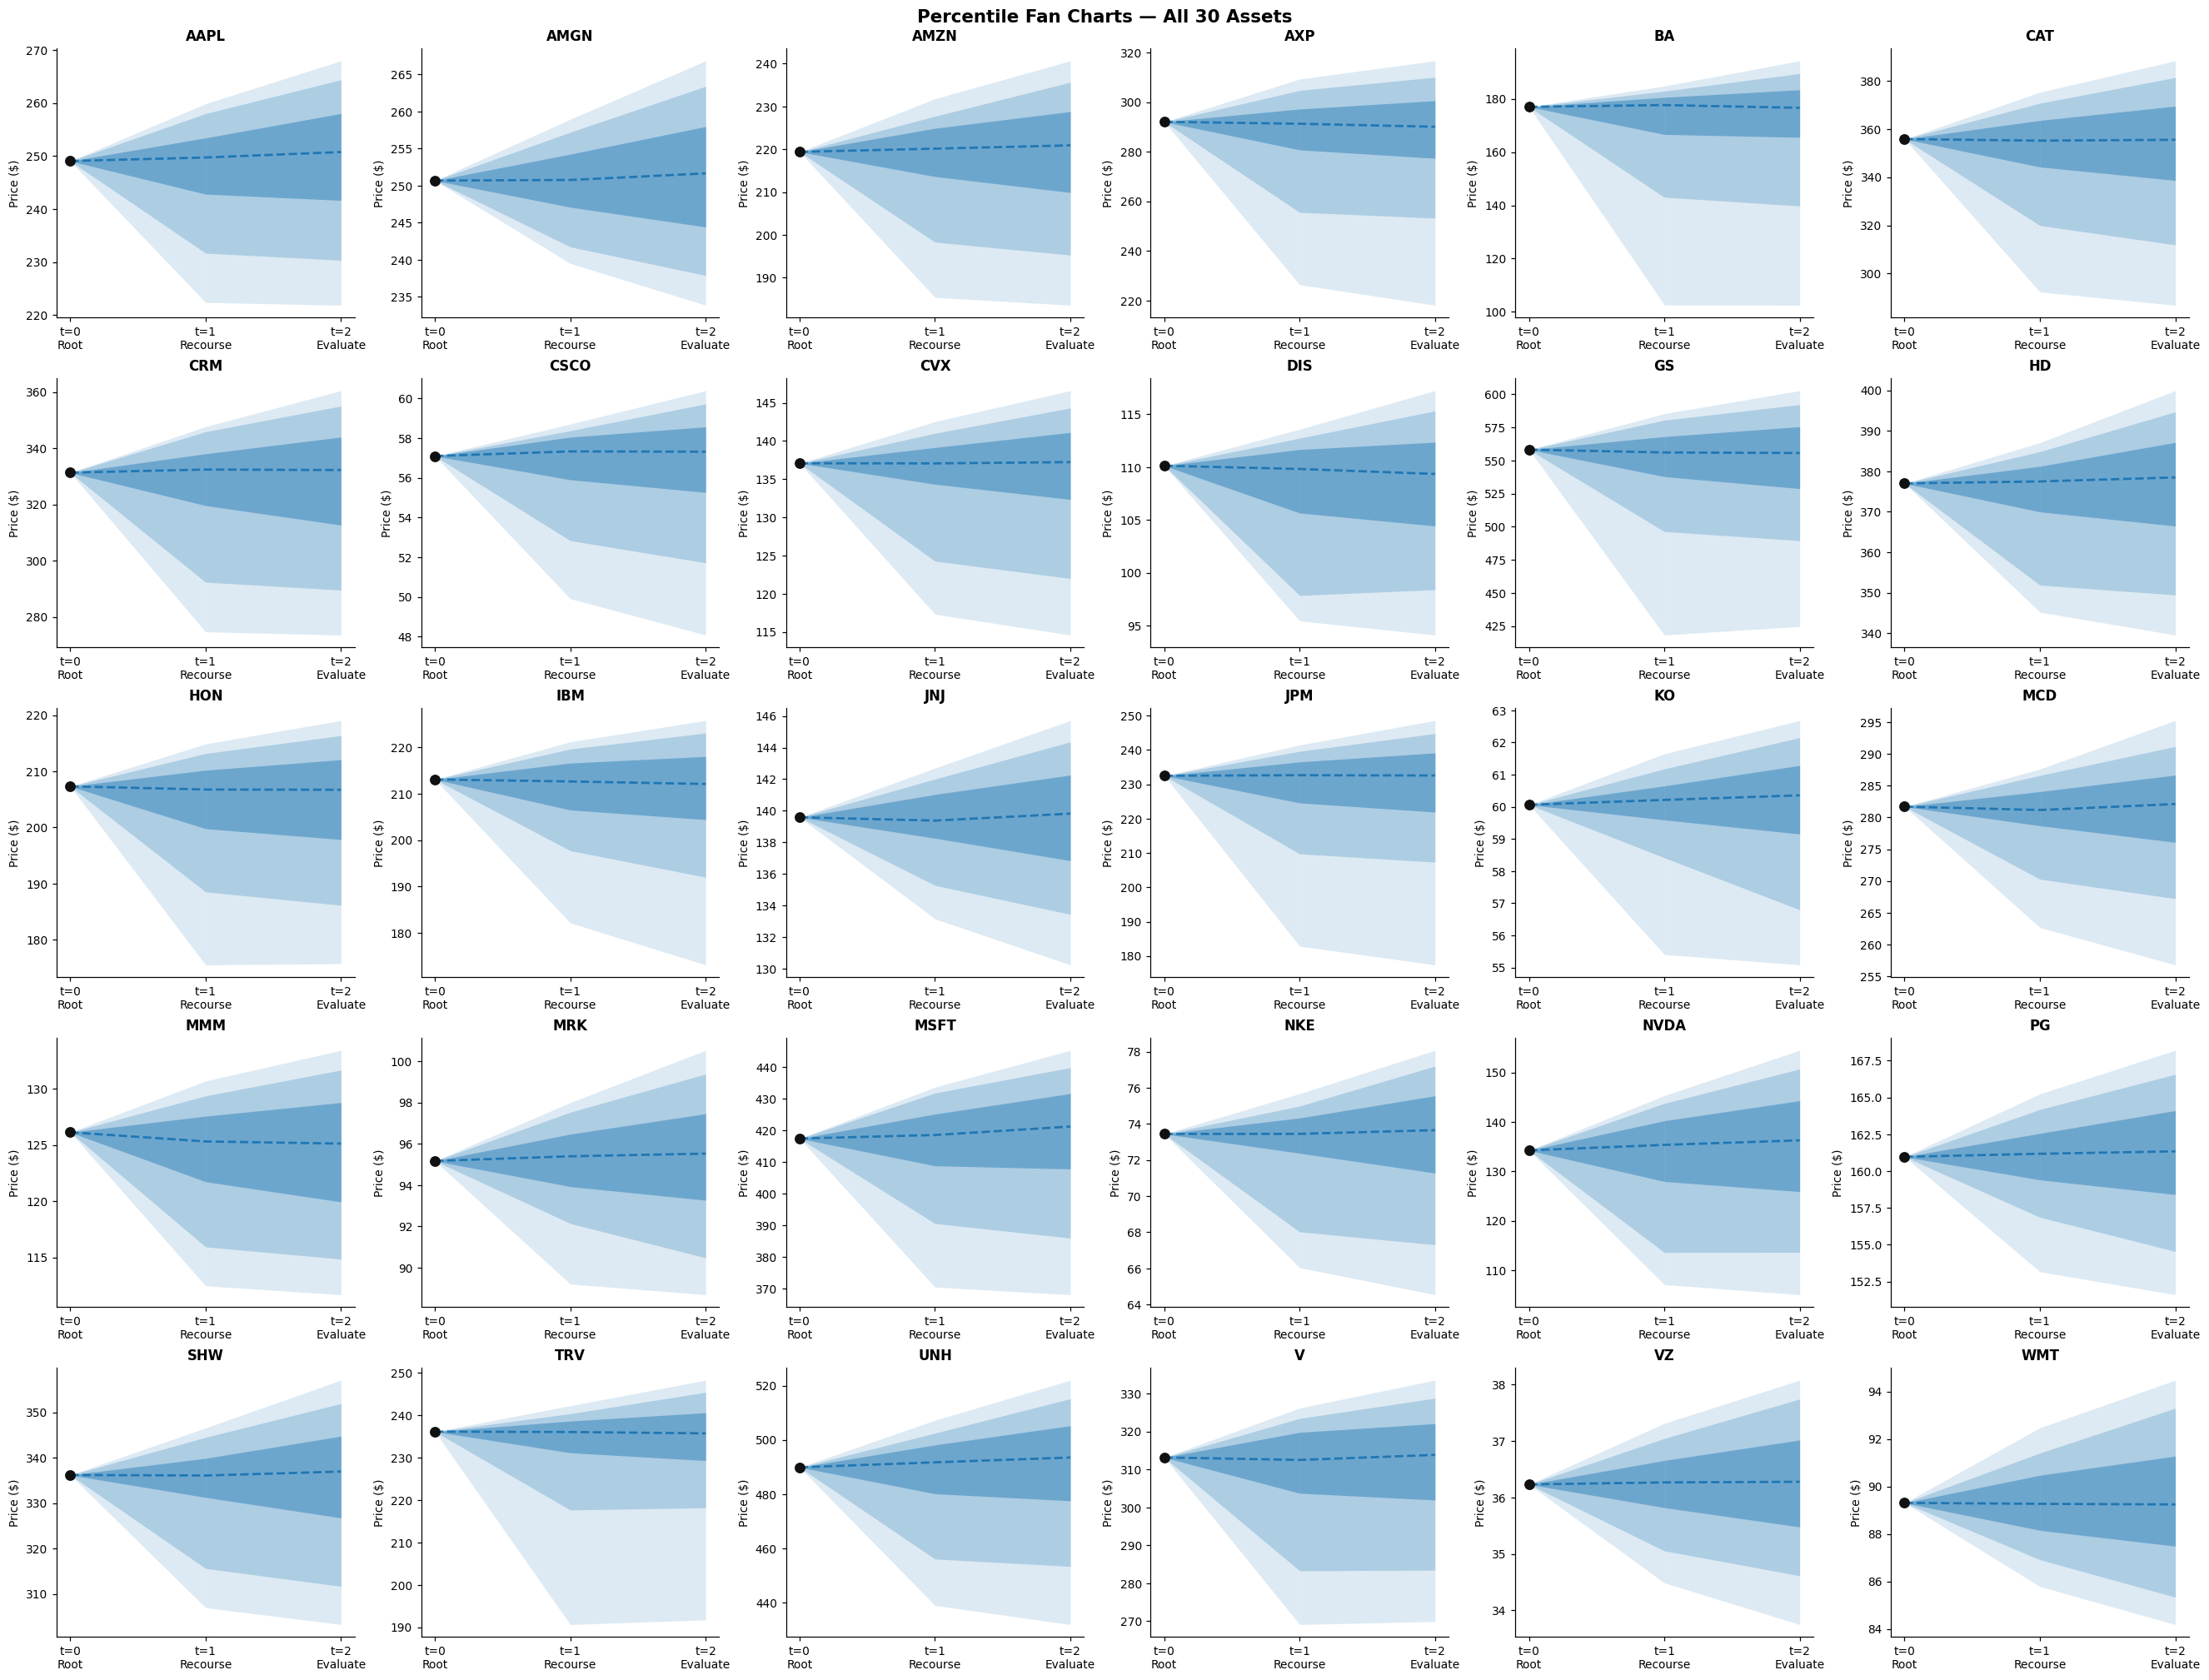

In [7]:
# ── all-assets percentile fan grid ───────────────────────────────────────────
fig, axes = plt.subplots(NROWS, NCOLS, figsize=(24, NROWS * 3.6), constrained_layout=True)
fig.suptitle('Percentile Fan Charts — All 30 Assets', fontsize=14, fontweight='bold', y=1.01)

for ax, ticker in zip(axes.ravel(), TICKERS):
    plot_percentile_fan(ticker, ax=ax)

for ax in axes.ravel()[N_ASSETS:]:
    ax.set_visible(False)

plt.show()

## Return Distributions

- **t=1 returns**: recourse prices relative to root  
- **t=2 conditional returns**: evaluate prices relative to their recourse parent (the second-stage shock)

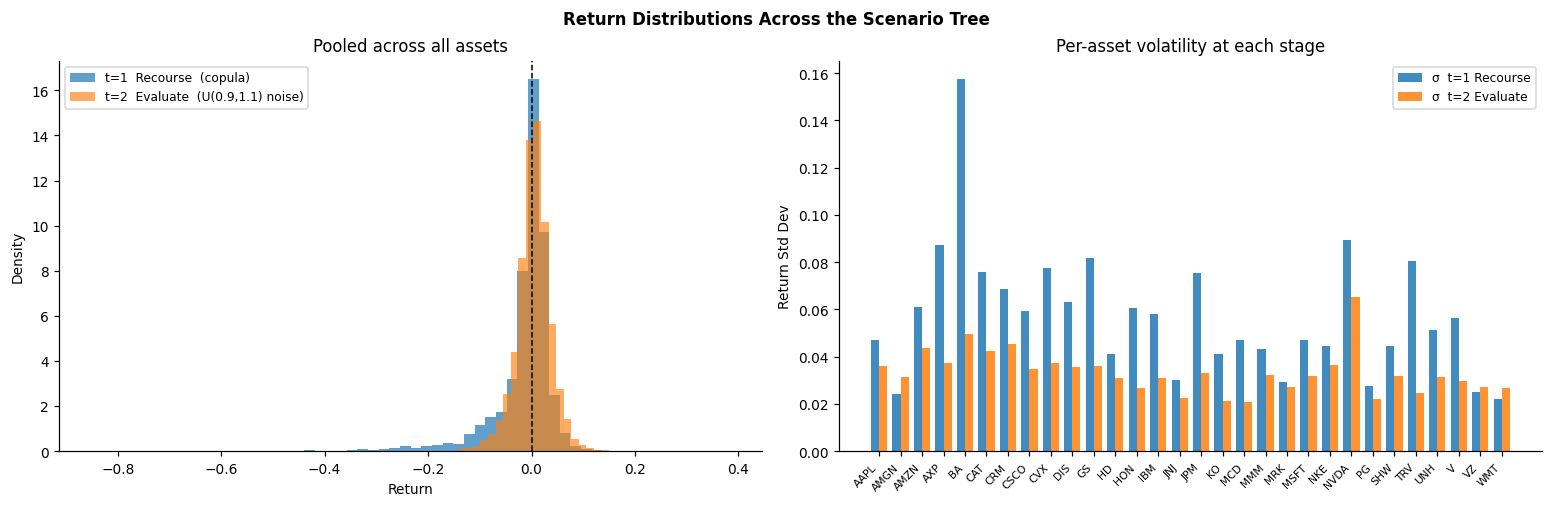

In [8]:
returns_t1      = recourse_prices / initial_prices[np.newaxis, :] - 1.0   # (400, 30)
returns_t2_cond = evaluate_prices / recourse_rep - 1.0                    # (16000, 30) — relative to parent

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
fig.suptitle('Return Distributions Across the Scenario Tree', fontweight='bold')

# ── left: pooled distribution ─────────────────────────────────────────────────
ax = axes[0]
ax.hist(returns_t1.ravel(), bins=60, density=True, alpha=0.7,
        color='#1f77b4', label='t=1  Recourse  (copula)')
ax.hist(returns_t2_cond.ravel(), bins=60, density=True, alpha=0.65,
        color='#ff7f0e', label='t=2  Evaluate  (U(0.9,1.1) noise)')
ax.axvline(0, color='black', lw=1, ls='--')
ax.set_xlabel('Return')
ax.set_ylabel('Density')
ax.set_title('Pooled across all assets')
ax.legend(fontsize=8)

# ── right: per-asset spread comparison ───────────────────────────────────────
ax = axes[1]
stds_t1 = returns_t1.std(axis=0)
stds_t2 = returns_t2_cond.std(axis=0)
x, w    = np.arange(N_ASSETS), 0.38
ax.bar(x - w/2, stds_t1, w, label='σ  t=1 Recourse',  color='#1f77b4', alpha=0.85)
ax.bar(x + w/2, stds_t2, w, label='σ  t=2 Evaluate',  color='#ff7f0e', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(TICKERS, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Return Std Dev')
ax.set_title('Per-asset volatility at each stage')
ax.legend(fontsize=8)

plt.show()

## Tree Statistics

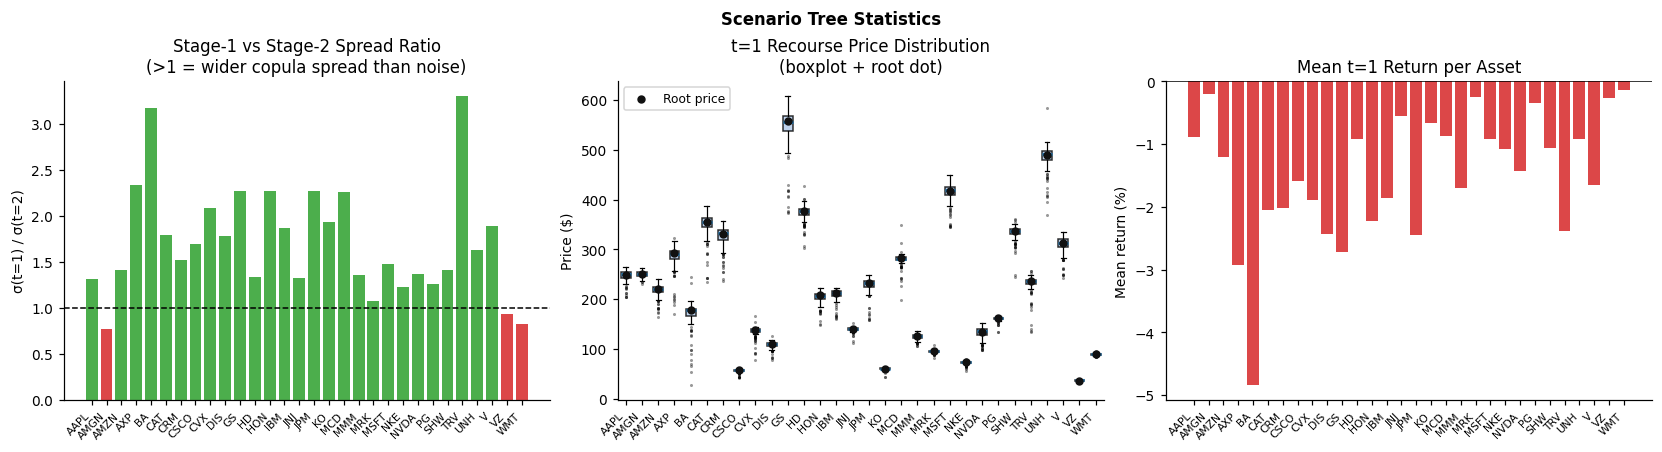

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
fig.suptitle('Scenario Tree Statistics', fontweight='bold')

# ── spread ratio (t=1 / t=2) per asset ───────────────────────────────────────
ax = axes[0]
spread_ratio = stds_t1 / stds_t2
colours = ['#2ca02c' if r >= 1 else '#d62728' for r in spread_ratio]
ax.bar(np.arange(N_ASSETS), spread_ratio, color=colours, alpha=0.85)
ax.axhline(1, color='black', lw=1, ls='--')
ax.set_xticks(np.arange(N_ASSETS))
ax.set_xticklabels(TICKERS, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('σ(t=1) / σ(t=2)')
ax.set_title('Stage-1 vs Stage-2 Spread Ratio\n(>1 = wider copula spread than noise)')

# ── distribution of t=1 prices for one asset (normalised) ────────────────────
ax = axes[1]
asset_show = TICKERS.index('AAPL')
ax.boxplot(
    [recourse_prices[:, i] for i in range(N_ASSETS)],
    positions=np.arange(N_ASSETS),
    widths=0.6,
    patch_artist=True,
    boxprops=dict(facecolor='#aec7e8', alpha=0.8),
    medianprops=dict(color='#1f77b4', lw=2),
    flierprops=dict(marker='.', ms=2, alpha=0.4),
    whiskerprops=dict(lw=0.8),
    capprops=dict(lw=0.8),
)
ax.scatter(np.arange(N_ASSETS), initial_prices, color='#111', s=20, zorder=5,
           label='Root price')
ax.set_xticks(np.arange(N_ASSETS))
ax.set_xticklabels(TICKERS, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Price ($)')
ax.set_title('t=1 Recourse Price Distribution\n(boxplot + root dot)')
ax.legend(fontsize=8)

# ── mean t=1 return per asset ─────────────────────────────────────────────────
ax = axes[2]
mean_t1 = returns_t1.mean(axis=0) * 100
bar_colours = ['#2ca02c' if m >= 0 else '#d62728' for m in mean_t1]
ax.bar(np.arange(N_ASSETS), mean_t1, color=bar_colours, alpha=0.85)
ax.axhline(0, color='black', lw=1)
ax.set_xticks(np.arange(N_ASSETS))
ax.set_xticklabels(TICKERS, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Mean return (%)')
ax.set_title('Mean t=1 Return per Asset')

plt.show()